In [ ]:
!wget -O images.pickle https://github.com/ichatnun/brainCodeCamp2023/raw/main/Fundamentals/DimensionalityReduction/data/CDT/clock_images.pickle
!wget -O labels.pickle https://github.com/ichatnun/brainCodeCamp2023/raw/main/Fundamentals/DimensionalityReduction/data/CDT/labels.pickle

--2024-11-04 03:06:52--  https://github.com/ichatnun/brainCodeCamp2023/raw/main/Fundamentals/DimensionalityReduction/data/CDT/clock_images.pickle
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/ichatnun/brainCodeCamp2023/main/Fundamentals/DimensionalityReduction/data/CDT/clock_images.pickle [following]
--2024-11-04 03:06:52--  https://raw.githubusercontent.com/ichatnun/brainCodeCamp2023/main/Fundamentals/DimensionalityReduction/data/CDT/clock_images.pickle
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1106083 (1.1M) [application/octet-stream]
Saving to: ‘images.pickle’

images.pickle       100

In [ ]:
import pickle
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate, cross_val_score
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.ensemble import GradientBoostingClassifier as GBC
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, KFold, StratifiedGroupKFold
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import ShuffleSplit

# ตั้งค่า random seed สำหรับการทำซ้ำ (reproducibility)
RANDOM_SEED = 2566

In [ ]:
with open('images.pickle', 'rb') as handle:
    images = pickle.load(handle)
with open('labels.pickle', 'rb') as handle:
    labels = pickle.load(handle)


In [ ]:
print(f"Images: {images.shape}")
print(f"Labels: {labels.shape}")
print(f"There are {images.shape[0]} samples. \nEach sample is an image of size {images.shape[1:]}.")

Images: (60, 48, 48)
Labels: (60,)
There are 60 samples. 
Each sample is an image of size (48, 48).


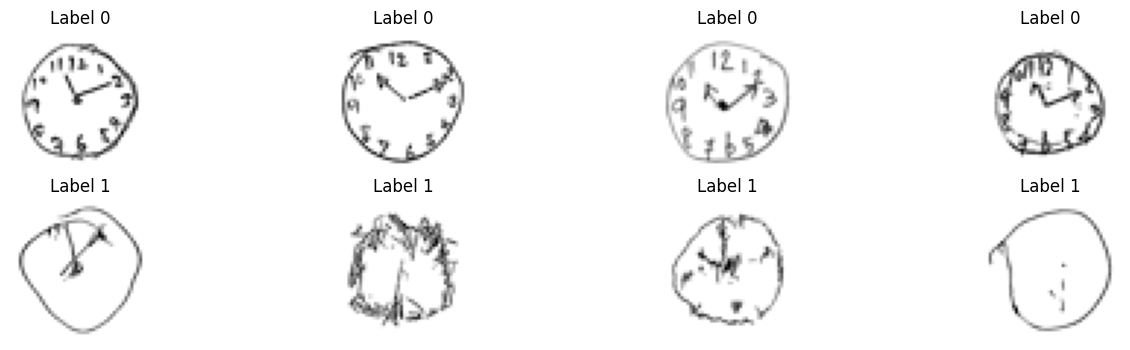

In [ ]:
num_img_to_display = 4
fig, ax = plt.subplots(2, num_img_to_display, figsize=(4*num_img_to_display, 4))

for curr_label in [0, 1]:
    curr_images = images[labels == curr_label, :][:num_img_to_display, :]

    for idx_img in range(num_img_to_display):
        ax[curr_label, idx_img].imshow(curr_images[idx_img], cmap='gray')
        ax[curr_label, idx_img].set_axis_off()
        ax[curr_label, idx_img].set_title(f"Label {curr_label}")

In [ ]:
# เตรียมข้อมูลที่มีการจัดเรียงมิติสอดคล้องกับความต้องการของ PCA (n_samples, n_features)
images_flatten = np.reshape(images, (images.shape[0],-1)) # changes 48x48 into one row
print(f"Current shape of our data: {images_flatten.shape}")

Current shape of our data: (60, 2304)


# PCA

In [ ]:
model_PCA = PCA(n_components=2, whiten=True, random_state=20) # whiten is linear transformation technique, random_state is to make the result reproducible.
images_PCA = model_PCA.fit_transform(images_flatten)

print(f"% variance captured by PC1 = {model_PCA.explained_variance_ratio_[0]*100: 0.2f}")
print(f"% variance captured by PC2 = {model_PCA.explained_variance_ratio_[1]*100: 0.2f}")
images_flatten.shape


% variance captured by PC1 =  8.84
% variance captured by PC2 =  7.58


(60, 2304)

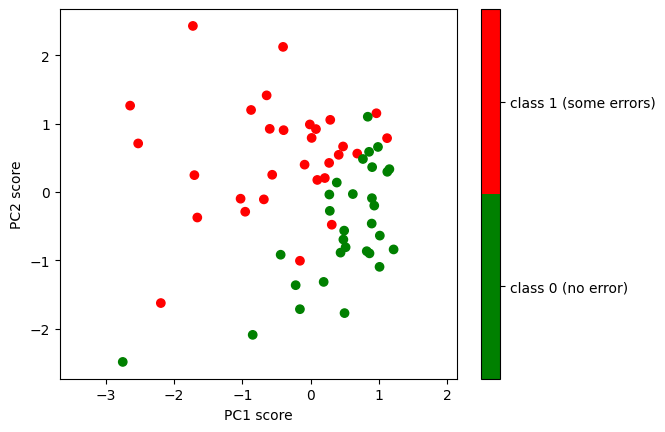

In [ ]:
# กำหนดสีให้แต่ละ class โดยใช้สีแดงแสดง class 1 (มีความผิดปกติ) และสีเขียวแสดง class 0 (ไม่มีความผิดปกติที่เห็นได้จากภาพวาด)
custom_cmap = colors.ListedColormap(["green","red"])

plt.figure()
plt.scatter(images_PCA[:, 0], images_PCA[:,1], c=labels, cmap=custom_cmap)
plt.gca().set_aspect('equal', 'datalim')
plt.colorbar(boundaries=np.arange(3)-0.5).set_ticks(np.arange(2), labels=['class 0 (no error)', 'class 1 (some errors)'])
plt.xlabel('PC1 score')
plt.ylabel('PC2 score')
plt.show()

# Logistic Regression





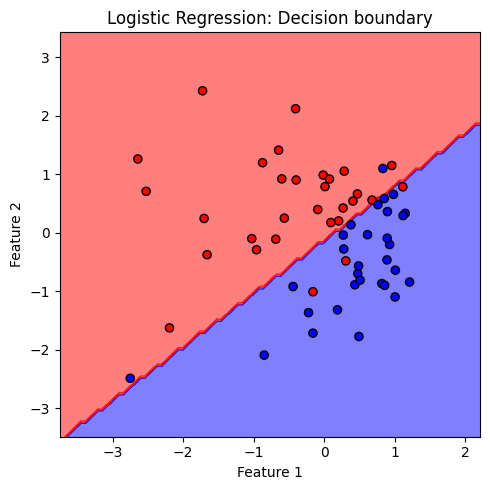

In [ ]:
# สร้างโมเดล
clf = LogisticRegression()
x = images_PCA
y = labels
# สอนโมเดลจากข้อมูล x, y ที่สร้างขึ้นก่อนหน้านี้
clf.fit(x, y)

# สร้าง cmap สำหรับแสดงผลตามสีแต่ละ class
cmap_2classes = colors.ListedColormap(['b', 'r'])

# plot the decision boundary
plt.figure(figsize = (5,5))
ax = plt.gca()
DecisionBoundaryDisplay.from_estimator(clf,
                                       x,
                                       response_method="predict",
                                       cmap=cmap_2classes,
                                       alpha=0.5,
                                       ax=ax,
                                       xlabel='Feature 1',
                                       ylabel='Feature 2'
                                       )
ax.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap_2classes, s=35, edgecolors='k')
plt.title('Logistic Regression: Decision boundary')
plt.tight_layout()
plt.show()

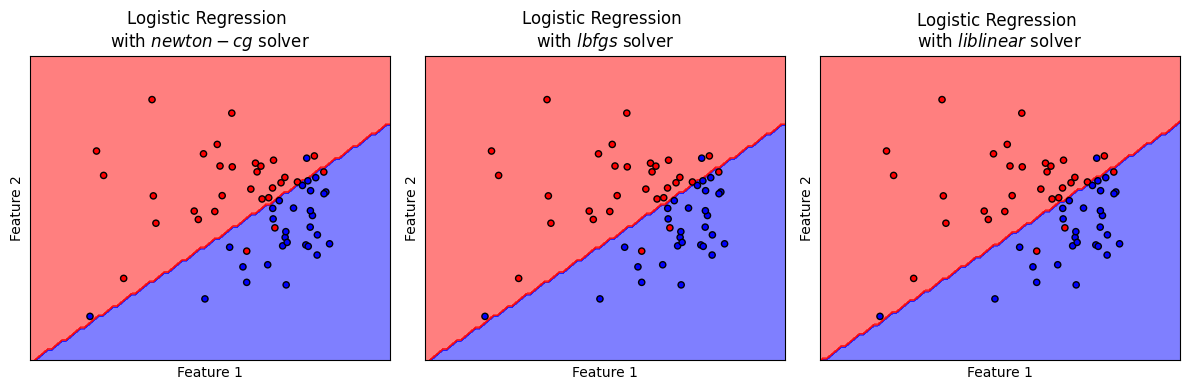

In [ ]:
# สร้างชุดโมเดล
models = (LogisticRegression(solver='newton-cg', max_iter=100, tol=1e-4),
          LogisticRegression(solver='lbfgs', max_iter=100, tol=1e-4),
          LogisticRegression(solver='liblinear', max_iter=100, tol=1e-4),
          )
# สอนโมเดลจากข้อมูล x, y ที่สร้างขึ้นก่อนหน้านี้
models = (clf.fit(x, y) for clf in models)

# ตั้งชื่อ plot ที่สอดคล้องกับชุดข้อมูล
titles = ['Logistic Regression \nwith $newton-cg$ solver',
          'Logistic Regression \nwith $lbfgs$ solver',
          'Logistic Regression \nwith $liblinear$ solver',
          ]

# plot the decision boundaries
fig, axes = plt.subplots(1,3, figsize=(12, 4))
for clf, title, ax in zip(models, titles, axes.flatten()):
    disp = DecisionBoundaryDisplay.from_estimator(clf,
                                                  x,
                                                  response_method="predict",
                                                  cmap=cmap_2classes,
                                                  alpha=0.5,
                                                  ax=ax,
                                                  xlabel='Feature 1',
                                                  ylabel='Feature 2',
                                                  )
    ax.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap_2classes, s=20, edgecolors='k')
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(title)
plt.tight_layout()
plt.show()

# Training and Testing Data

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4, stratify=None, random_state=RANDOM_SEED)
print('Train set: จำนวนข้อมูล แบ่งกลุ่มตาม class label')
unique, counts = np.unique(y_train, return_counts=True)
print(np.asarray((unique, counts)).T)

print('Test set: จำนวนข้อมูล แบ่งกลุ่มตาม class label')
unique, counts = np.unique(y_test, return_counts=True)
print(np.asarray((unique, counts)).T)

Train set: จำนวนข้อมูล แบ่งกลุ่มตาม class label
[[ 0 19]
 [ 1 17]]
Test set: จำนวนข้อมูล แบ่งกลุ่มตาม class label
[[ 0 11]
 [ 1 13]]


In [ ]:
# สร้าง standardized scaler จาก features ใน training data
x_scaler = StandardScaler().fit(x_train)

# scale ค่า features ใน training data และ test data
x_train = x_scaler.transform(x_train)
x_test  = x_scaler.transform(x_test)

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
for train, test in skf.split(x,y):
    skf_x_train, skf_y_train = x[train], y[train]
    skf_x_test, skf_y_test = x[test], y[test]
skf.get_n_splits(x,y)

5

Training Set: Classification report
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        19
           1       0.88      0.88      0.88        17

    accuracy                           0.89        36
   macro avg       0.89      0.89      0.89        36
weighted avg       0.89      0.89      0.89        36


Test Set: Classification report
              precision    recall  f1-score   support

           0       0.73      1.00      0.85        11
           1       1.00      0.69      0.82        13

    accuracy                           0.83        24
   macro avg       0.87      0.85      0.83        24
weighted avg       0.88      0.83      0.83        24



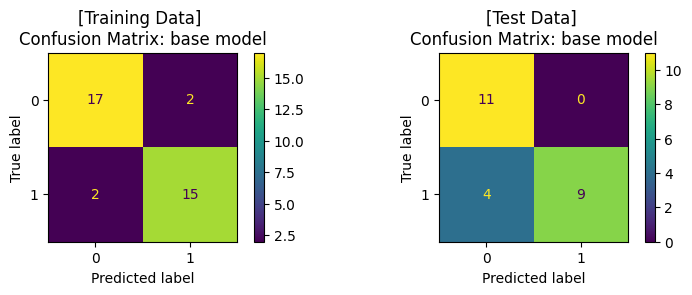

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

# สร้างโมเดล
base_clf = LogisticRegression(random_state=RANDOM_SEED)

# สอนโมเดลด้วย training data
base_clf.fit(x_train,y_train)

# ให้โมเดลทำนาย training data
y_pred = base_clf.predict(x_train)

# แสดงผล classification ของโมเดลจาก training data
print('Training Set: Classification report')
print(classification_report(y_train, y_pred))

# คำนวนและแสดงผล confusion matrix ของ training data
cm = confusion_matrix(y_train, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(ax=ax1)
ax1.set_title('[Training Data] \nConfusion Matrix: base model')

# ให้โมเดลทำนาย test data
y_pred = base_clf.predict(x_test)

# แสดงผล classification ของโมเดล
print('\nTest Set: Classification report')
print(classification_report(y_test, y_pred))

# คำนวนและแสดงผล confusion matrix ของ test set
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(ax=ax2)
ax2.set_title('[Test Data] \nConfusion Matrix: base model')

plt.tight_layout()
plt.show()

In [ ]:
scores=cross_val_score(base_clf, x, y, scoring='f1_macro',cv=5)
mean = np.round(np.mean(scores),2)
mean

0.9

In [ ]:
model = LogisticRegression()
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}
grid_search = GridSearchCV(model, param_grid, cv=5)
grid_search.fit(x_train, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)

{'C': 100, 'penalty': 'l2'}
0.8928571428571429


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
30 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py", line 1194, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "/us

In [ ]:
y_pred = grid_search.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      1.00      0.88        11
           1       1.00      0.77      0.87        13

    accuracy                           0.88        24
   macro avg       0.89      0.88      0.87        24
weighted avg       0.90      0.88      0.87        24



Training Set: Classification report
              precision    recall  f1-score   support

           0       0.91      0.88      0.89        24
           1       0.88      0.92      0.90        24

    accuracy                           0.90        48
   macro avg       0.90      0.90      0.90        48
weighted avg       0.90      0.90      0.90        48


Test Set: Classification report
              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       0.86      1.00      0.92         6

    accuracy                           0.92        12
   macro avg       0.93      0.92      0.92        12
weighted avg       0.93      0.92      0.92        12



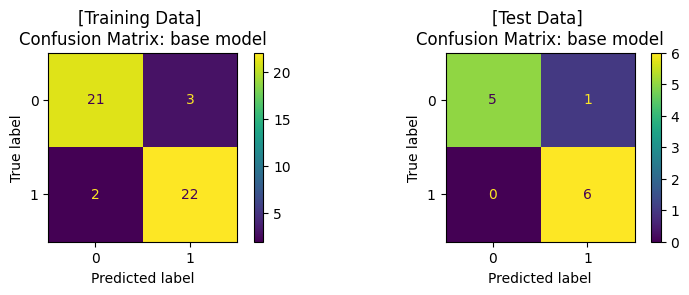

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

# สร้างโมเดล
base_clf = LogisticRegression(random_state=RANDOM_SEED)

# สอนโมเดลด้วย training data
base_clf.fit(skf_x_train,skf_y_train)

# ให้โมเดลทำนาย training data
y_pred = base_clf.predict(skf_x_train)

# แสดงผล classification ของโมเดลจาก training data
print('Training Set: Classification report')
print(classification_report(skf_y_train, y_pred))

# คำนวนและแสดงผล confusion matrix ของ training data
cm = confusion_matrix(skf_y_train, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(ax=ax1)
ax1.set_title('[Training Data] \nConfusion Matrix: base model')

# ให้โมเดลทำนาย test data
y_pred = base_clf.predict(skf_x_test)

# แสดงผล classification ของโมเดล
print('\nTest Set: Classification report')
print(classification_report(skf_y_test, y_pred))

# คำนวนและแสดงผล confusion matrix ของ test set
cm = confusion_matrix(skf_y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(ax=ax2)
ax2.set_title('[Test Data] \nConfusion Matrix: base model')

plt.tight_layout()
plt.show()

# Ignore SGKF
I was testing purely out of curiosity if the result would be the same as SKF but outcome is different. I suspect that it is just the randomization not being the same.

In [ ]:
sgkf = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
groups = list(range(60))
for train, test in sgkf.split(x,y,groups=groups):
    sgkf_x_train, sgkf_y_train = x[train], y[train]
    sgkf_x_test, sgkf_y_test = x[test], y[test]

Training Set: Classification report
              precision    recall  f1-score   support

           0       0.90      0.95      0.93        20
           1       0.95      0.90      0.92        20

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.92        40
weighted avg       0.93      0.93      0.92        40


Test Set: Classification report
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.90      0.90      0.90        10

    accuracy                           0.90        20
   macro avg       0.90      0.90      0.90        20
weighted avg       0.90      0.90      0.90        20



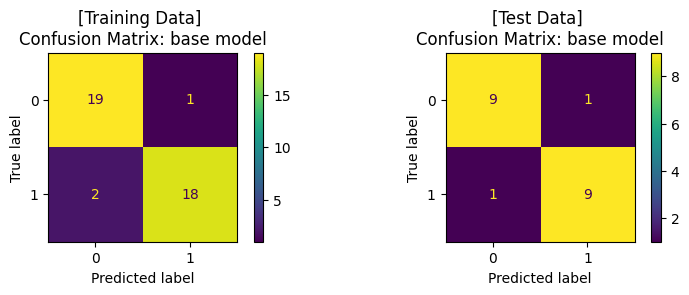

In [ ]:
# prompt: take the skf's logistic regression and confusion matrix but make the variable name sgkf instead

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

# สร้างโมเดล
base_clf = LogisticRegression(random_state=RANDOM_SEED)

# สอนโมเดลด้วย training data
base_clf.fit(sgkf_x_train,sgkf_y_train)

# ให้โมเดลทำนาย training data
y_pred = base_clf.predict(sgkf_x_train)

# แสดงผล classification ของโมเดลจาก training data
print('Training Set: Classification report')
print(classification_report(sgkf_y_train, y_pred))

# คำนวนและแสดงผล confusion matrix ของ training data
cm = confusion_matrix(sgkf_y_train, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(ax=ax1)
ax1.set_title('[Training Data] \nConfusion Matrix: base model')

# ให้โมเดลทำนาย test data
y_pred = base_clf.predict(sgkf_x_test)

# แสดงผล classification ของโมเดล
print('\nTest Set: Classification report')
print(classification_report(sgkf_y_test, y_pred))

# คำนวนและแสดงผล confusion matrix ของ test set
cm = confusion_matrix(sgkf_y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(ax=ax2)
ax2.set_title('[Test Data] \nConfusion Matrix: base model')

plt.tight_layout()
plt.show()

# SVM


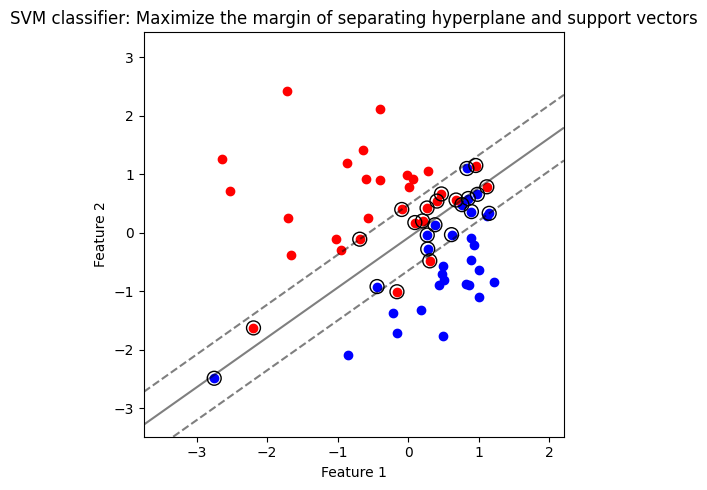

In [ ]:
# สร้างโมเดล
clf = SVC(kernel='linear', random_state=RANDOM_SEED)

# สอนโมเดลจากข้อมูล x, y ที่สร้างขึ้นก่อนหน้านี้
clf.fit(x, y)

# Plot ข้อมูล x, y
plt.figure(figsize = (5,5))
plt.scatter(x[y==0, 0], x[y==0, 1], c='b', label='Class 0')
plt.scatter(x[y==1, 0], x[y==1, 1], c='r', label='Class 0')

# plot the decision function
ax = plt.gca()
DecisionBoundaryDisplay.from_estimator(clf,
                                       x,
                                       plot_method="contour",
                                       colors="k",
                                       levels=[-1, 0, 1],
                                       alpha=0.5,
                                       linestyles=["--", "-", "--"],
                                       ax=ax)

# plot support vectors
ax.scatter(clf.support_vectors_[:, 0],
           clf.support_vectors_[:, 1],
           s=100, linewidth=1,
           facecolors='none',
           edgecolors='k'
           )
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVM classifier: Maximize the margin of separating hyperplane and support vectors')
plt.tight_layout()
plt.show()

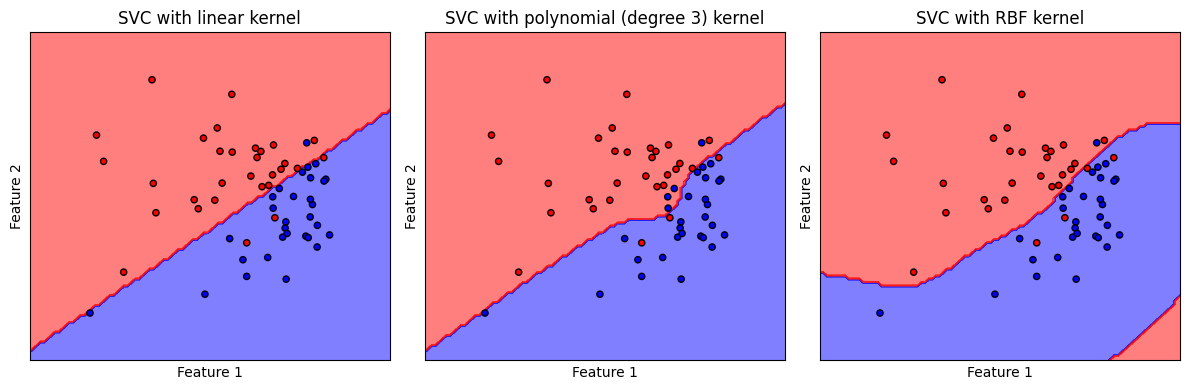

In [ ]:
# สร้างชุดโมเดล
models = (SVC(kernel='linear', random_state=RANDOM_SEED),
          SVC(kernel='poly', degree=3, random_state=RANDOM_SEED),
          SVC(kernel='rbf', random_state=RANDOM_SEED),
          )

# สอนโมเดลจากข้อมูล x, y ที่สร้างขึ้นก่อนหน้านี้
models = (clf.fit(x, y) for clf in models)

# สร้าง cmap สำหรับแสดงผลตามสีแต่ละ class
cmap_2classes = colors.ListedColormap(['b', 'r'])

# ตั้งชื่อ plot ที่สอดคล้องกับชุดข้อมูล
titles = ['SVC with linear kernel',
          'SVC with polynomial (degree 3) kernel',
          'SVC with RBF kernel',
          ]

# plot the decision boundaries
fig, axes = plt.subplots(1,3, figsize=(12, 4))
for clf, title, ax in zip(models, titles, axes.flatten()):
    disp = DecisionBoundaryDisplay.from_estimator(clf,
                                                  x,
                                                  response_method="predict",
                                                  cmap=cmap_2classes,
                                                  alpha=0.5,
                                                  ax=ax,
                                                  xlabel='Feature 1',
                                                  ylabel='Feature 2',
                                                  )
    ax.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap_2classes, s=20, edgecolors='k')
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(title)
plt.tight_layout()
plt.show()

Training Set: Classification report
              precision    recall  f1-score   support

           0       0.94      0.89      0.92        19
           1       0.89      0.94      0.91        17

    accuracy                           0.92        36
   macro avg       0.92      0.92      0.92        36
weighted avg       0.92      0.92      0.92        36


Test Set: Classification report
              precision    recall  f1-score   support

           0       0.73      1.00      0.85        11
           1       1.00      0.69      0.82        13

    accuracy                           0.83        24
   macro avg       0.87      0.85      0.83        24
weighted avg       0.88      0.83      0.83        24



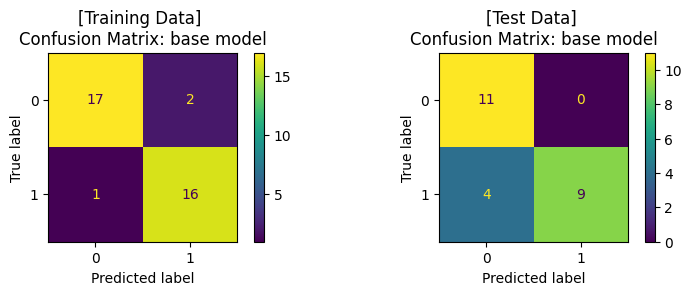

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

# สร้างโมเดล
base_clf = SVC(kernel='linear', random_state=RANDOM_SEED)

# สอนโมเดลด้วย training data
base_clf.fit(x_train,y_train)

# ให้โมเดลทำนาย training data
y_pred = base_clf.predict(x_train)

# แสดงผล classification ของโมเดลจาก training data
print('Training Set: Classification report')
print(classification_report(y_train, y_pred))

# คำนวนและแสดงผล confusion matrix ของ training data
cm = confusion_matrix(y_train, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(ax=ax1)
ax1.set_title('[Training Data] \nConfusion Matrix: base model')

# ให้โมเดลทำนาย test data
y_pred = base_clf.predict(x_test)

# แสดงผล classification ของโมเดล
print('\nTest Set: Classification report')
print(classification_report(y_test, y_pred))

# คำนวนและแสดงผล confusion matrix ของ test set
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(ax=ax2)
ax2.set_title('[Test Data] \nConfusion Matrix: base model')

plt.tight_layout()
plt.show()

Training Set: Classification report
              precision    recall  f1-score   support

           0       0.86      1.00      0.92        24
           1       1.00      0.83      0.91        24

    accuracy                           0.92        48
   macro avg       0.93      0.92      0.92        48
weighted avg       0.93      0.92      0.92        48


Test Set: Classification report
              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       0.83      0.83      0.83         6

    accuracy                           0.83        12
   macro avg       0.83      0.83      0.83        12
weighted avg       0.83      0.83      0.83        12



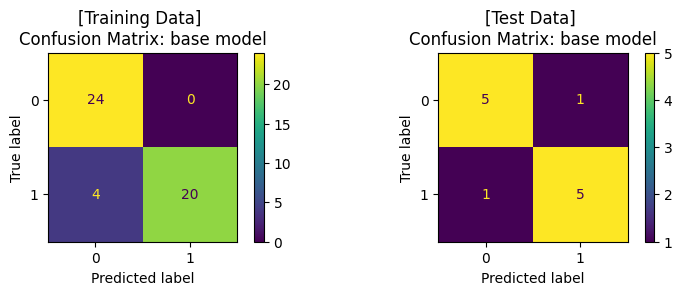

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

# สร้างโมเดล
base_clf = SVC(kernel='rbf', random_state=RANDOM_SEED)

# สอนโมเดลด้วย training data
base_clf.fit(skf_x_train,skf_y_train)

# ให้โมเดลทำนาย training data
y_pred = base_clf.predict(skf_x_train)

# แสดงผล classification ของโมเดลจาก training data
print('Training Set: Classification report')
print(classification_report(skf_y_train, y_pred))

# คำนวนและแสดงผล confusion matrix ของ training data
cm = confusion_matrix(skf_y_train, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(ax=ax1)
ax1.set_title('[Training Data] \nConfusion Matrix: base model')

# ให้โมเดลทำนาย test data
y_pred = base_clf.predict(skf_x_test)

# แสดงผล classification ของโมเดล
print('\nTest Set: Classification report')
print(classification_report(skf_y_test, y_pred))

# คำนวนและแสดงผล confusion matrix ของ test set
cm = confusion_matrix(skf_y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(ax=ax2)
ax2.set_title('[Test Data] \nConfusion Matrix: base model')

plt.tight_layout()
plt.show()

DT & RF

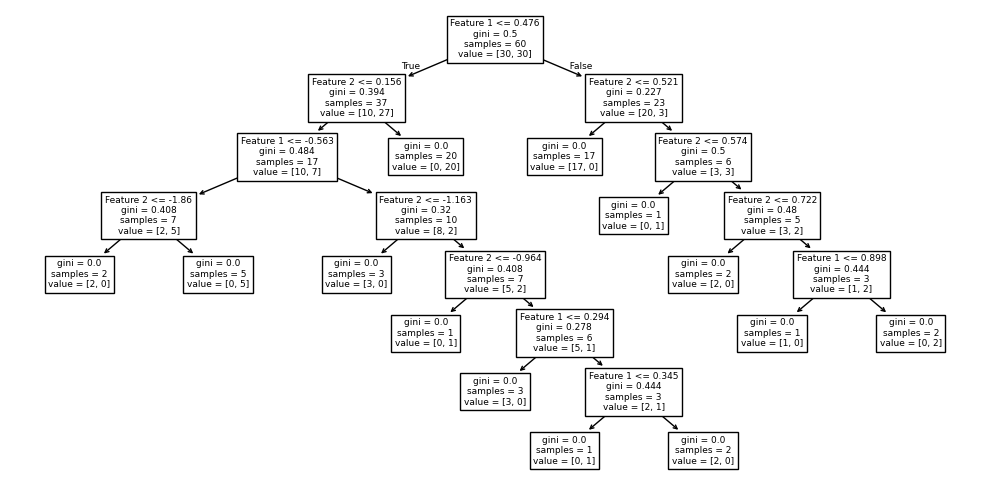

In [ ]:
# สร้างชุดโมเดลด้วย default hyperparameters โดยกำหนดค่า `random_state`
# เพื่อให้ได้โมเดลเดิมทุกครั้งที่เรียนรู้จากข้อมูลชุดเดิมสำหรับการสอน
clf = DTC(random_state=RANDOM_SEED)

# สอนโมเดลจากข้อมูล x, y ที่สร้างขึ้นก่อนหน้านี้
clf.fit(x, y)

# Plot Decision Tree
plt.figure(figsize = (10,5))
tree.plot_tree(clf, feature_names=['Feature 1','Feature 2'])
plt.tight_layout()
plt.show()

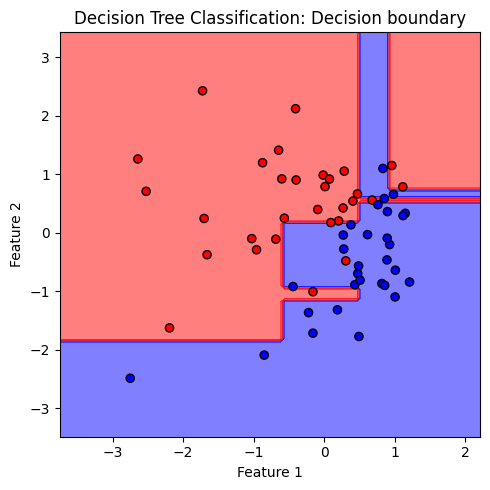

In [ ]:
# สร้าง cmap สำหรับแสดงผลตามสีแต่ละ class
cmap_2classes = colors.ListedColormap(['b', 'r'])

# plot the decision boundary
plt.figure(figsize = (5,5))
ax = plt.gca()
DecisionBoundaryDisplay.from_estimator(clf,
                                       x,
                                       response_method="predict",
                                       cmap=cmap_2classes,
                                       alpha=0.5,
                                       ax=ax,
                                       xlabel='Feature 1',
                                       ylabel='Feature 2'
                                       )
ax.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap_2classes, s=35, edgecolors='k')
plt.title('Decision Tree Classification: Decision boundary')
plt.tight_layout()
plt.show()

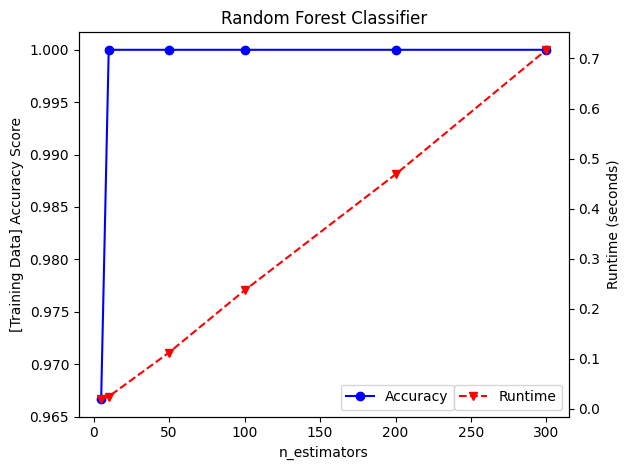

In [ ]:
import time

# กำหนดช่วงค่าต้นไม้ หรือ n_estimators
n_estimators = [5,10,50,100,200,300]

# สร้างโมเดลด้วค่า C ต่างๆ ให้โมเดลเรียนรู้จากข้อมูล x, y ที่สร้างขึ้นก่อนหน้านี้
# แล้วทดสอบโมเดลด้วย accuracy score จาก training data
accuracy = []
runtimes = []
for n in n_estimators:
    start_time = time.time()  # เริ่มจับเวลา

    # สร้างชุดโมเดล โดยกำหนดค่า `random_state`
    # เพื่อให้ได้โมเดลเดิมทุกครั้งที่เรียนรู้จากข้อมูลชุดเดิมสำหรับการสอน
    clf = RFC(n_estimators=n, random_state=RANDOM_SEED)

    # สอนโมเดลจากข้อมูล x, y ที่สร้างขึ้นก่อนหน้านี้
    clf.fit(x, y)

    runtimes.append((time.time() - start_time)) # หยุดจับเวลา

    # ทำนายค่า y โดยใช้โมเดล
    prediction = clf.predict(x)

    # คำนวณ accuracy score
    accuracy.append(accuracy_score(y, prediction))

# แสดงผล
fig, ax1 = plt.subplots()
ax1.plot(n_estimators, accuracy, 'bo-', label='Accuracy')
ax1.set_xlabel('n_estimators')
ax1.set_ylabel('[Training Data] Accuracy Score')
ax1.legend(loc='lower center', bbox_to_anchor=(0.65, 0))

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
plt.plot(n_estimators, runtimes, 'rv--', label='Runtime')
ax2.set_ylabel('Runtime (seconds)')
ax2.legend(loc='lower right')

plt.title('Random Forest Classifier')
#plt.legend()
plt.tight_layout()
plt.show()

Number of Decision Trees: 100


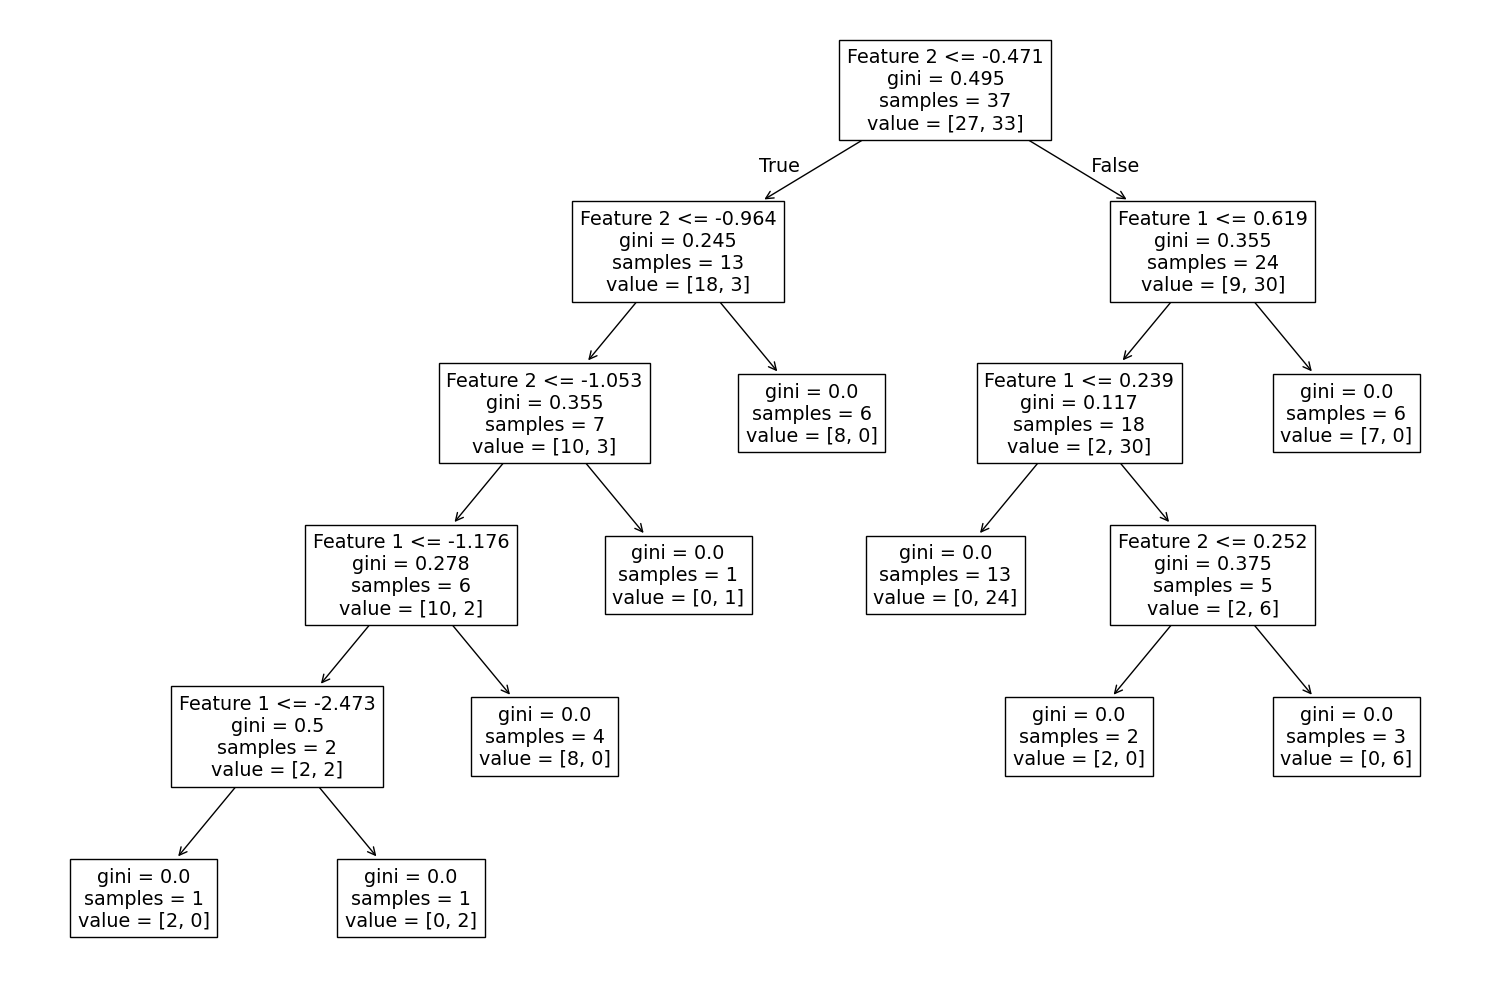

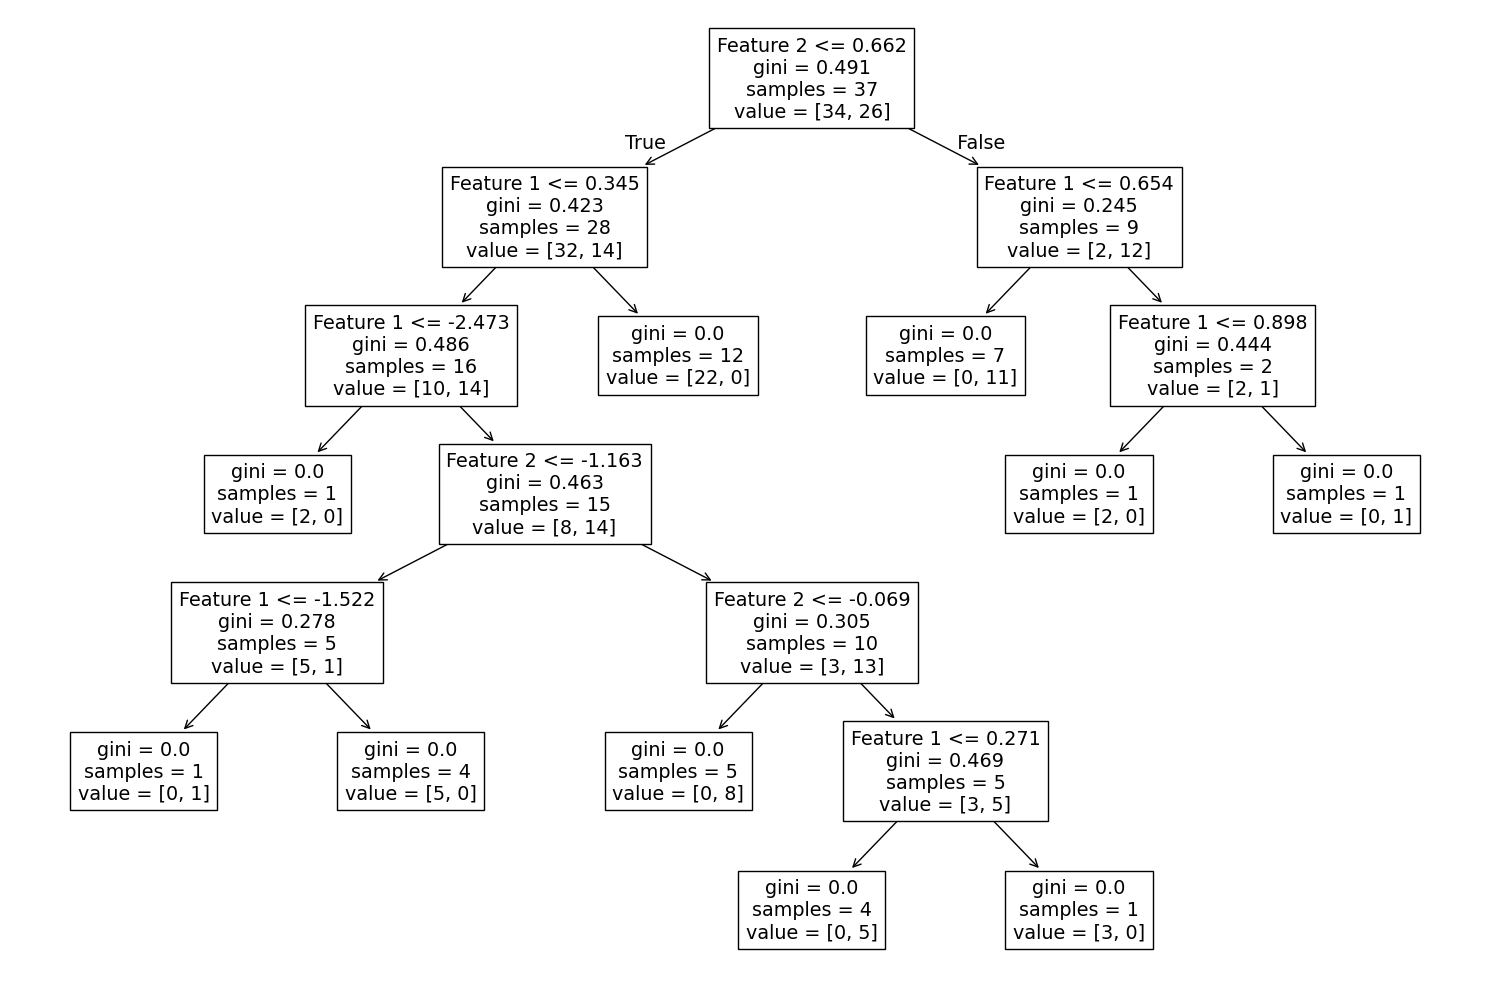

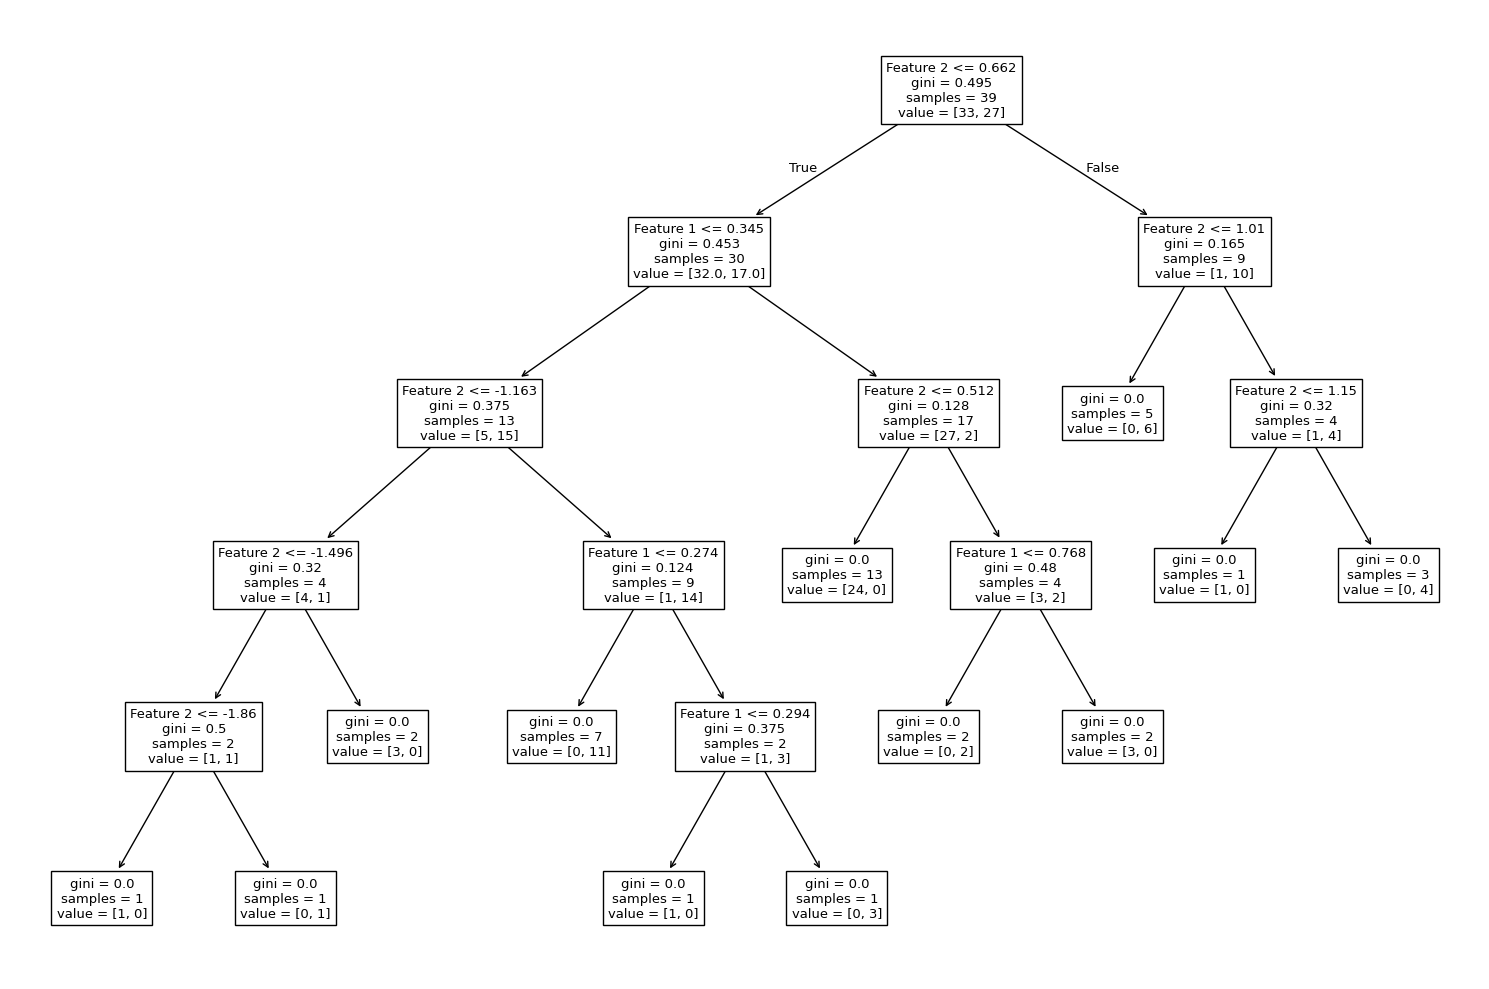

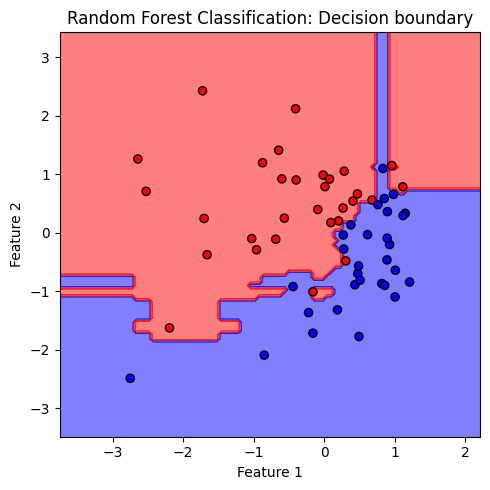

In [ ]:
# สร้างชุดโมเดลด้วย default hyperparameters โดยกำหนดค่า `random_state`
# เพื่อให้ได้โมเดลเดิมทุกครั้งที่เรียนรู้จากข้อมูลชุดเดิมสำหรับการสอน
clf = RFC(n_estimators=100, random_state=RANDOM_SEED)

# สอนโมเดลจากข้อมูล x, y ที่สร้างขึ้นก่อนหน้านี้
clf.fit(x, y)

# แสดงจำนวนต้นไม้
print('Number of Decision Trees:', clf.n_estimators)

# Plot Decision Tree แสดง decision path ของต้นไม้ 3 ต้นแรกจากโมเดล random forest
for i in range(3):
    plt.figure(figsize = (15,10))
    tree.plot_tree(clf.estimators_[i], feature_names=['Feature 1','Feature 2'])
    plt.tight_layout()
plt.show()

# plot the decision boundary
plt.figure(figsize = (5,5))
ax = plt.gca()
DecisionBoundaryDisplay.from_estimator(clf,
                                       x,
                                       response_method="predict",
                                       cmap=cmap_2classes,
                                       alpha=0.5,
                                       ax=ax,
                                       xlabel='Feature 1',
                                       ylabel='Feature 2'
                                       )
ax.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap_2classes, s=35, edgecolors='k')
plt.title('Random Forest Classification: Decision boundary')
plt.tight_layout()
plt.show()

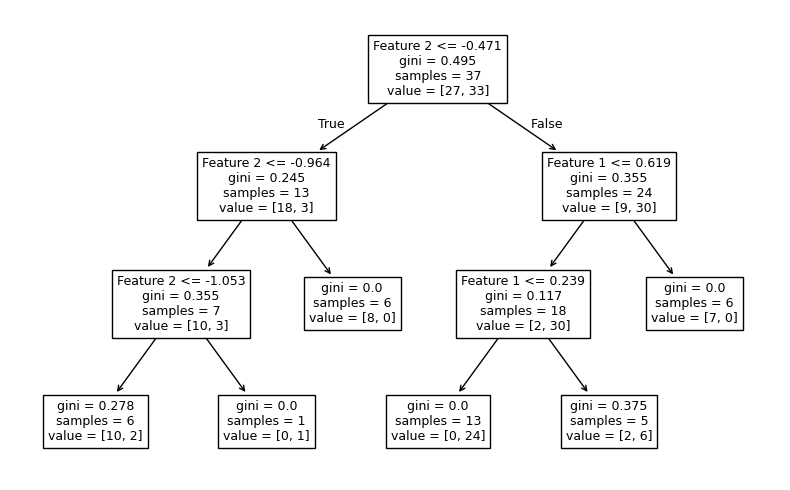

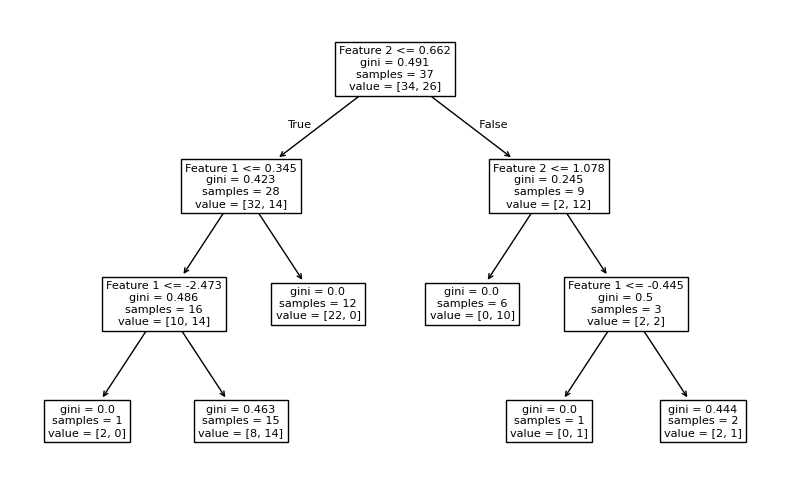

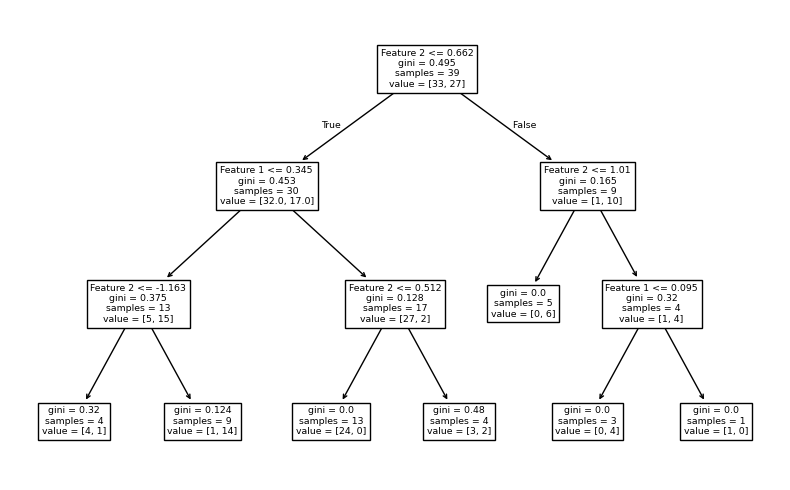

In [ ]:
# สร้างชุดโมเดล
clf = RFC(n_estimators=100, max_depth=3, random_state=RANDOM_SEED)

# สอนโมเดลจากข้อมูล x, y ที่สร้างขึ้นก่อนหน้านี้
clf.fit(x, y)

# Plot Decision Tree แสดง decision path ของต้นไม้ 3 ต้นแรกจากโมเดล random forest
for i in range(3):
    plt.figure(figsize = (8,5))
    tree.plot_tree(clf.estimators_[i],feature_names=['Feature 1','Feature 2'])
    plt.tight_layout()
plt.show()

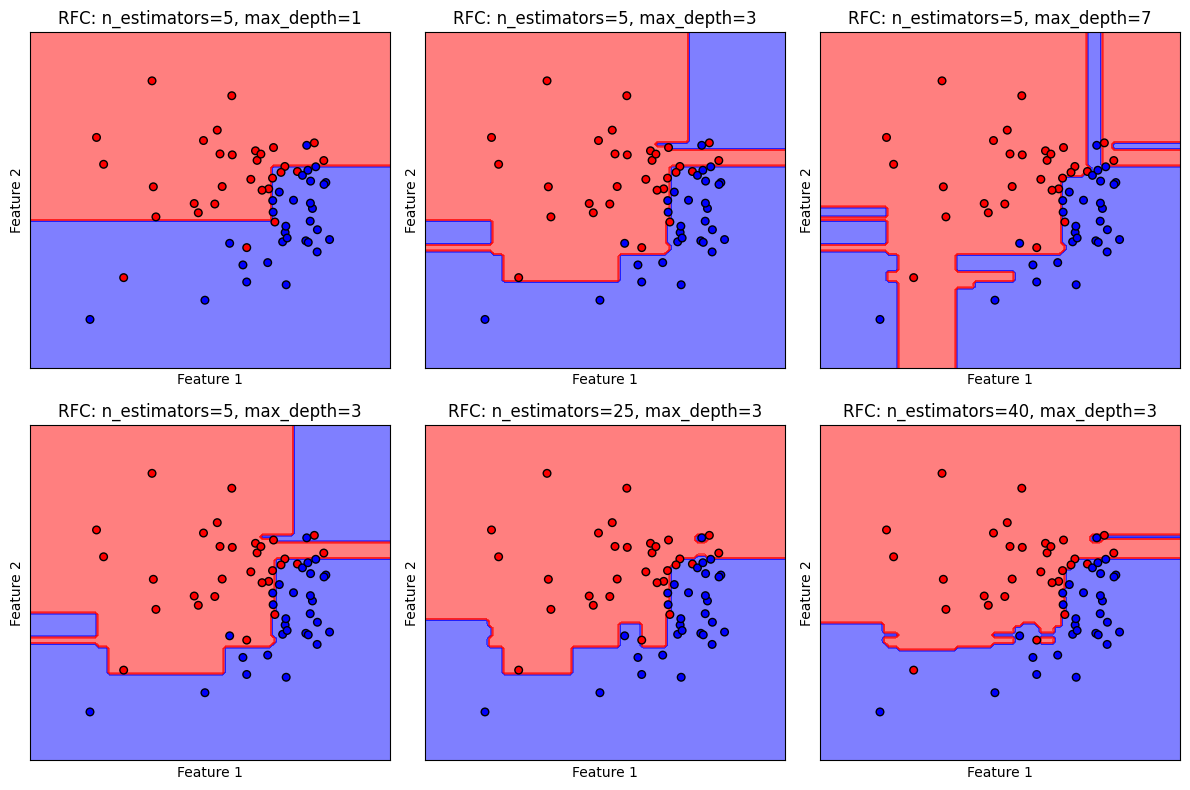

In [ ]:
# สร้างชุดโมเดล
models = [RFC(n_estimators=5, max_depth=1, random_state=RANDOM_SEED),
          RFC(n_estimators=5, max_depth=3, random_state=RANDOM_SEED),
          RFC(n_estimators=5, max_depth=7, random_state=RANDOM_SEED),
          RFC(n_estimators=5, max_depth=3, random_state=RANDOM_SEED),
          RFC(n_estimators=25, max_depth=3, random_state=RANDOM_SEED),
          RFC(n_estimators=40, max_depth=3, random_state=RANDOM_SEED)
          ]

# สอนโมเดลจากข้อมูล x, y ที่สร้างขึ้นก่อนหน้านี้
models = [clf.fit(x, y) for clf in models]

# ตั้งชื่อ plot ที่สอดคล้องกับชุดข้อมูล
titles = ['RFC: n_estimators=5, max_depth=1',
          'RFC: n_estimators=5, max_depth=3',
          'RFC: n_estimators=5, max_depth=7',
          'RFC: n_estimators=5, max_depth=3',
          'RFC: n_estimators=25, max_depth=3',
          'RFC: n_estimators=40, max_depth=3',
          ]

# plot the decision boundaries
fig, axes = plt.subplots(2,3, figsize=(4*3, 4*2))
for clf, title, ax in zip(models, titles, axes.flatten()):
    disp = DecisionBoundaryDisplay.from_estimator(clf,
                                                  x,
                                                  response_method="predict",
                                                  cmap=cmap_2classes,
                                                  alpha=0.5,
                                                  ax=ax,
                                                  xlabel='Feature 1',
                                                  ylabel='Feature 2',
                                                  )
    ax.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap_2classes, s=30, edgecolors='k')
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(title)
plt.tight_layout()
plt.show()

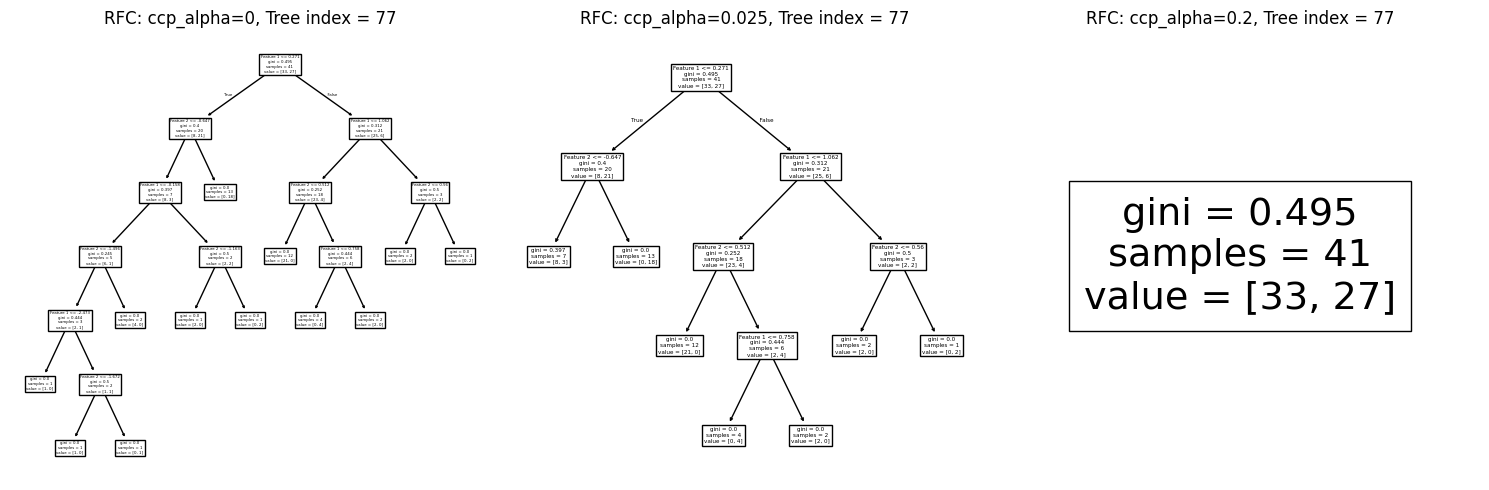

In [ ]:
# สร้างชุดโมเดล
models = [RFC(n_estimators=100, max_depth=None, ccp_alpha=0, random_state=RANDOM_SEED),
          RFC(n_estimators=100, max_depth=None, ccp_alpha=0.025, random_state=RANDOM_SEED),
          RFC(n_estimators=100, max_depth=None, ccp_alpha=0.2, random_state=RANDOM_SEED)
          ]

# สอนโมเดลจากข้อมูล x, y ที่สร้างขึ้นก่อนหน้านี้
fit_models = [clf.fit(x, y) for clf in models]
# ตั้งชื่อ plot ที่สอดคล้องกับชุดข้อมูล
titles = ['RFC: ccp_alpha=0',
          'RFC: ccp_alpha=0.025',
          'RFC: ccp_alpha=0.2'
          ]

# Plot Decision Tree แสดง decision path ของต้นไม้ 1 ต้นที่สุ่มเลือกจากโมเดล random forest
i = np.random.randint(100)
fig, axes = plt.subplots(1,3, figsize=(15, 5))
for clf, title, ax in zip(fit_models, titles, axes.flatten()):
    tree.plot_tree(clf.estimators_[i], feature_names=['Feature 1','Feature 2'], ax=ax)
    ax.set_title(title+', Tree index = {}'.format(i))
plt.tight_layout()
plt.show()

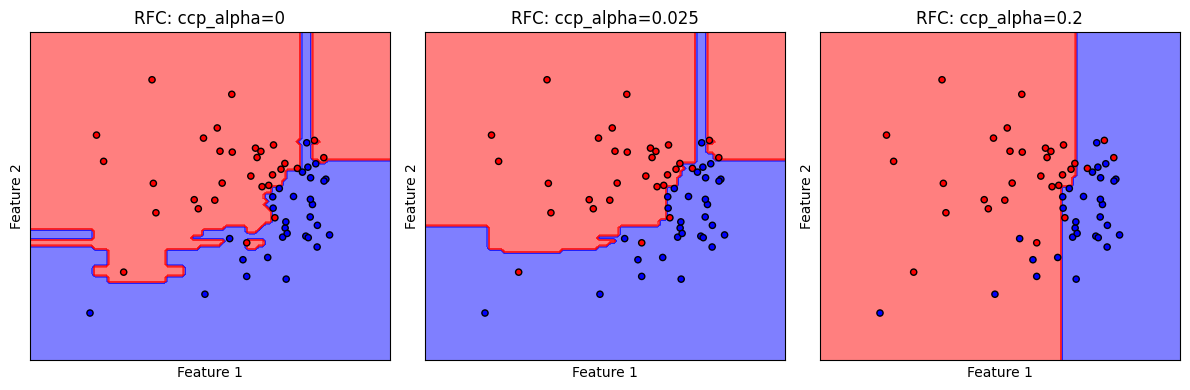

In [ ]:
# ตั้งชื่อ plot ที่สอดคล้องกับชุดข้อมูล
titles = ['RFC: ccp_alpha=0',
          'RFC: ccp_alpha=0.025',
          'RFC: ccp_alpha=0.2'
          ]

# plot the decision boundaries
fig, axes = plt.subplots(1,3, figsize=(12, 4))
for clf, title, ax in zip(models, titles, axes.flatten()):
    disp = DecisionBoundaryDisplay.from_estimator(clf,
                                                  x,
                                                  response_method="predict",
                                                  cmap=cmap_2classes,
                                                  alpha=0.5,
                                                  ax=ax,
                                                  xlabel='Feature 1',
                                                  ylabel='Feature 2',
                                                  )
    ax.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap_2classes, s=20, edgecolors='k')
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(title)
plt.tight_layout()
plt.show()

Training Set: Classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        17

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


Test Set: Classification report
              precision    recall  f1-score   support

           0       0.73      1.00      0.85        11
           1       1.00      0.69      0.82        13

    accuracy                           0.83        24
   macro avg       0.87      0.85      0.83        24
weighted avg       0.88      0.83      0.83        24



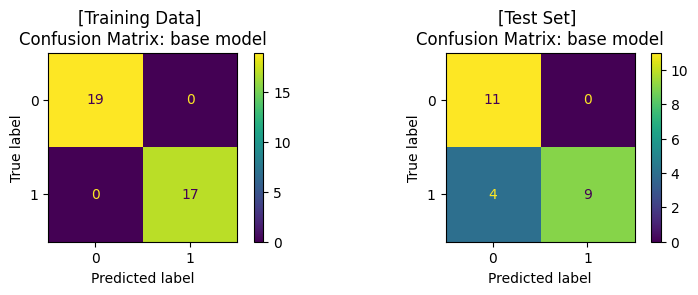

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

# สร้างโมเดล
base_clf = RFC(n_estimators=28, max_depth=None, ccp_alpha=0.025, random_state=RANDOM_SEED)

# สอนโมเดลด้วย training data
base_clf.fit(x_train,y_train)

# ให้โมเดลทำนาย training data
y_pred = base_clf.predict(x_train)

# แสดงผล classification ของโมเดลจาก training data
print('Training Set: Classification report')
print(classification_report(y_train, y_pred))

# คำนวนและแสดงผล confusion matrix ของ training data
cm = confusion_matrix(y_train, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(ax=ax1)
ax1.set_title('[Training Data] \nConfusion Matrix: base model')

# ให้โมเดลทำนาย test data
y_pred = base_clf.predict(x_test)

# แสดงผล classification ของโมเดล
print('\nTest Set: Classification report')
print(classification_report(y_test, y_pred))

# คำนวนและแสดงผล confusion matrix ของ test set
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(ax=ax2)
ax2.set_title('[Test Set] \nConfusion Matrix: base model')

plt.tight_layout()
plt.show()

In [ ]:
scores=cross_val_score(base_clf, x, y, scoring='f1_macro',cv=5)
scores

array([0.58041958, 0.74825175, 0.83333333, 0.91608392, 1.        ])

Training Set: Classification report
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.94      0.97        17

    accuracy                           0.97        36
   macro avg       0.97      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36


Test Set: Classification report
              precision    recall  f1-score   support

           0       0.73      1.00      0.85        11
           1       1.00      0.69      0.82        13

    accuracy                           0.83        24
   macro avg       0.87      0.85      0.83        24
weighted avg       0.88      0.83      0.83        24



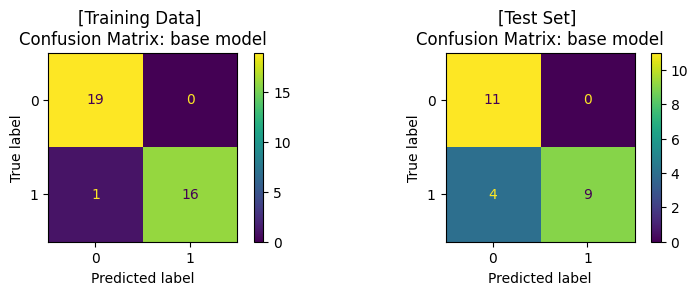

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

# สร้างโมเดล
base_clf = RFC(n_estimators=100, max_depth=3, random_state=RANDOM_SEED)

# สอนโมเดลด้วย training data
base_clf.fit(x_train,y_train)

# ให้โมเดลทำนาย training data
y_pred = base_clf.predict(x_train)

# แสดงผล classification ของโมเดลจาก training data
print('Training Set: Classification report')
print(classification_report(y_train, y_pred))

# คำนวนและแสดงผล confusion matrix ของ training data
cm = confusion_matrix(y_train, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(ax=ax1)
ax1.set_title('[Training Data] \nConfusion Matrix: base model')

# ให้โมเดลทำนาย test data
y_pred = base_clf.predict(x_test)

# แสดงผล classification ของโมเดล
print('\nTest Set: Classification report')
print(classification_report(y_test, y_pred))

# คำนวนและแสดงผล confusion matrix ของ test set
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(ax=ax2)
ax2.set_title('[Test Set] \nConfusion Matrix: base model')

plt.tight_layout()
plt.show()

In [ ]:
scores=cross_val_score(base_clf, x, y, scoring='f1_macro',cv=5)
np.mean(scores)

0.7986013986013987

Training Set: Classification report
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        24
           1       1.00      0.96      0.98        24

    accuracy                           0.98        48
   macro avg       0.98      0.98      0.98        48
weighted avg       0.98      0.98      0.98        48


Test Set: Classification report
              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       0.83      0.83      0.83         6

    accuracy                           0.83        12
   macro avg       0.83      0.83      0.83        12
weighted avg       0.83      0.83      0.83        12



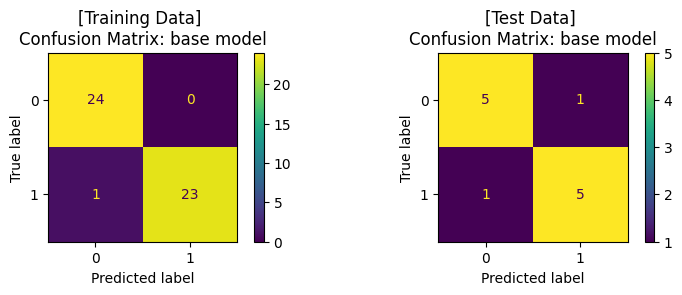

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

# สร้างโมเดล
base_clf = RFC(n_estimators=25, max_depth=None, ccp_alpha=0.025, random_state=RANDOM_SEED)

# สอนโมเดลด้วย training data
base_clf.fit(skf_x_train,skf_y_train)

# ให้โมเดลทำนาย training data
y_pred = base_clf.predict(skf_x_train)

# แสดงผล classification ของโมเดลจาก training data
print('Training Set: Classification report')
print(classification_report(skf_y_train, y_pred))

# คำนวนและแสดงผล confusion matrix ของ training data
cm = confusion_matrix(skf_y_train, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(ax=ax1)
ax1.set_title('[Training Data] \nConfusion Matrix: base model')

# ให้โมเดลทำนาย test data
y_pred = base_clf.predict(skf_x_test)

# แสดงผล classification ของโมเดล
print('\nTest Set: Classification report')
print(classification_report(skf_y_test, y_pred))

# คำนวนและแสดงผล confusion matrix ของ test set
cm = confusion_matrix(skf_y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(ax=ax2)
ax2.set_title('[Test Data] \nConfusion Matrix: base model')

plt.tight_layout()
plt.show()

# GBC

Training Set: Classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        17

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


Test Set: Classification report
              precision    recall  f1-score   support

           0       0.73      1.00      0.85        11
           1       1.00      0.69      0.82        13

    accuracy                           0.83        24
   macro avg       0.87      0.85      0.83        24
weighted avg       0.88      0.83      0.83        24



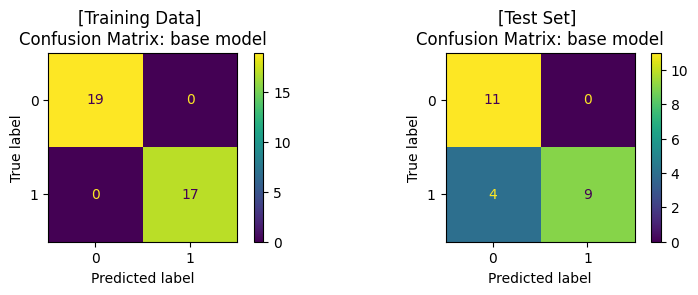

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

# สร้างโมเดล
base_clf = GBC(learning_rate=0.1, n_estimators=25,random_state=RANDOM_SEED)

# สอนโมเดลด้วย training data
base_clf.fit(x_train,y_train)

# ให้โมเดลทำนาย training data
y_pred = base_clf.predict(x_train)

# แสดงผล classification ของโมเดลจาก training data
print('Training Set: Classification report')
print(classification_report(y_train, y_pred))

# คำนวนและแสดงผล confusion matrix ของ training data
cm = confusion_matrix(y_train, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(ax=ax1)
ax1.set_title('[Training Data] \nConfusion Matrix: base model')

# ให้โมเดลทำนาย test data
y_pred = base_clf.predict(x_test)

# แสดงผล classification ของโมเดล
print('\nTest Set: Classification report')
print(classification_report(y_test, y_pred))

# คำนวนและแสดงผล confusion matrix ของ test set
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(ax=ax2)
ax2.set_title('[Test Set] \nConfusion Matrix: base model')

plt.tight_layout()
plt.show()

Training Set: Classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        24

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48


Test Set: Classification report
              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       0.83      0.83      0.83         6

    accuracy                           0.83        12
   macro avg       0.83      0.83      0.83        12
weighted avg       0.83      0.83      0.83        12



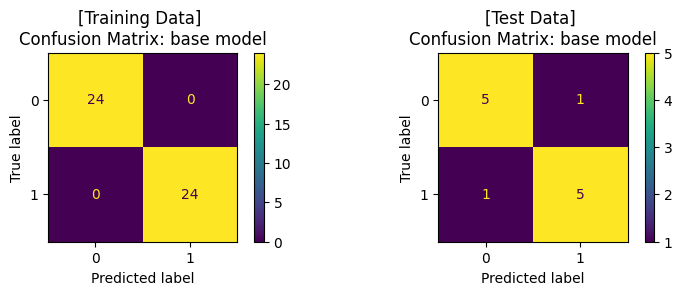

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

# สร้างโมเดล
base_clf = GBC(learning_rate=0.1, n_estimators=25,random_state=RANDOM_SEED)

# สอนโมเดลด้วย training data
base_clf.fit(skf_x_train,skf_y_train)

# ให้โมเดลทำนาย training data
y_pred = base_clf.predict(skf_x_train)

# แสดงผล classification ของโมเดลจาก training data
print('Training Set: Classification report')
print(classification_report(skf_y_train, y_pred))

# คำนวนและแสดงผล confusion matrix ของ training data
cm = confusion_matrix(skf_y_train, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(ax=ax1)
ax1.set_title('[Training Data] \nConfusion Matrix: base model')

# ให้โมเดลทำนาย test data
y_pred = base_clf.predict(skf_x_test)

# แสดงผล classification ของโมเดล
print('\nTest Set: Classification report')
print(classification_report(skf_y_test, y_pred))

# คำนวนและแสดงผล confusion matrix ของ test set
cm = confusion_matrix(skf_y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(ax=ax2)
ax2.set_title('[Test Data] \nConfusion Matrix: base model')

plt.tight_layout()
plt.show()